## IMPORTING LIBRARIES ##

In [1]:
import pandas as pd
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## LOADING DATASET ##

In [3]:
df = pd.read_csv("movies.csv", encoding='latin1')
print(df.head())

                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2       Roy Angana  
3  Siddhant Kapoor  
4    

In [4]:
print(df.columns)

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')


## HANDLING MISSING VALUES ##

In [6]:
df = df.dropna()

## CLEANING Duration & Year ##

In [7]:
df['Duration'] = df['Duration'].astype(str)
df['Duration'] = df['Duration'].str.extract('(\d+)')
df['Duration'] = df['Duration'].astype(float)

In [8]:
df['Year'] = df['Year'].astype(str)
df['Year'] = df['Year'].str.extract('(\d+)')
df['Year'] = df['Year'].astype(float)

## ENCODING CATEGORICAL DATA ##

In [9]:
le_genre = LabelEncoder()
le_director = LabelEncoder()
le_actor1 = LabelEncoder()
le_actor2 = LabelEncoder()
le_actor3 = LabelEncoder()
df['Genre'] = le_genre.fit_transform(df['Genre'].astype(str))
df['Director'] = le_director.fit_transform(df['Director'].astype(str))
df['Actor 1'] = le_actor1.fit_transform(df['Actor 1'].astype(str))
df['Actor 2'] = le_actor2.fit_transform(df['Actor 2'].astype(str))
df['Actor 3'] = le_actor3.fit_transform(df['Actor 3'].astype(str))

In [10]:
X = df[['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Duration', 'Year']]
y = df['Rating']

In [12]:
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.mean())
y = pd.to_numeric(y, errors='coerce')
y = y.fillna(y.mean())
print(X.dtypes)

Genre         int64
Director      int64
Actor 1       int64
Actor 2       int64
Actor 3       int64
Duration    float64
Year        float64
dtype: object


## TRAIN-TEST ##

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## TRAINING MODEL USNG REGRESSION ##

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## PREDICTION ##

In [15]:
y_pred = model.predict(X_test)

In [16]:
##evaluating
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 1.7556246297446663
R2 Score: 0.05190730184889969


## VISUALIZATION ##

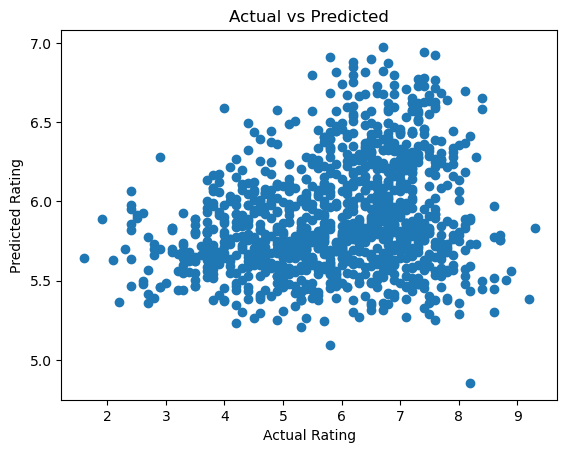

In [17]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted")
plt.show()

## SAVING MODEL ##

In [18]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [19]:
# Save encoders
pickle.dump(le_genre, open("genre.pkl", "wb"))
pickle.dump(le_director, open("director.pkl", "wb"))
pickle.dump(le_actor1, open("actor1.pkl", "wb"))
pickle.dump(le_actor2, open("actor2.pkl", "wb"))
pickle.dump(le_actor3, open("actor3.pkl", "wb"))